# Mini Project: Customer Churn Analysis

**Domain:** Telecommunications & Subscription Services  
**Role:** Data Analyst  
**Objective:** Analyze customer demographic, service, contract, billing, and churn information using Python (Pandas, NumPy, Matplotlib, Seaborn) and Power BI to identify behavioral patterns associated with customer churn and provide data-driven retention strategies.  
**Tools & Technologies:** Python 3, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook, Power BI Desktop, DAX, Power Query.

---
## Project Workflow Structure
- **Part 1 — Data Loading (Steps 1 to 6)**
- **Part 2 — Data Exploration & Cleaning (Steps 7 to 16)**
- **Part 3 — Data Analysis (Steps 17 to 38)**
- **Part 4 — Python Visualizations (14 Charts)**
- **Part 5 — Power BI Dashboard Integration & DAX Measures**
- **Part 6 — Business Insights & Answers to 10 Key Analytical Questions**


---
# PART 1 — DATA LOADING

In this section, we import the required analytical and visualization libraries, load the raw customer dataset, inspect initial records, examine the dimensionality, and list all feature attributes.


In [1]:
# Step 1: Import the required libraries
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Set aesthetic visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 140

print("Core libraries imported successfully.")


Core libraries imported successfully.


In [2]:
# Step 2: Load the dataset using Pandas
raw_data_path = os.path.join("..", "Dataset", "Customer_Churn_Raw.csv")
if not os.path.exists(raw_data_path):
    raw_data_path = os.path.join("Dataset", "Customer_Churn_Raw.csv")

df = pd.read_csv(raw_data_path)
print(f"Dataset successfully loaded from: {raw_data_path}")


Dataset successfully loaded from: Dataset\Customer_Churn_Raw.csv


In [3]:
# Step 3: Display the first five records
df.head()


,Customer_ID,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,8725-JEDFD,Male,0,No,No,27,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,69.05,1793.25,No
1,2651-ZCBXV,Male,0,No,No,54,Yes,Yes,Fiber optic,Yes,...,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),108.00,5760.65,No
2,2077-MPJQO,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.40,533.05,No
3,1342-JPNKI,Male,0,No,No,10,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),86.05,834.1,Yes
4,0188-GWFLE,Male,0,No,No,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,33.7,No


In [4]:
# Step 4: Display the last five records
df.tail()


,Customer_ID,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
7056,0684-AOSIH,Male,0,Yes,No,1,Yes,No,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.00,95,Yes
7057,5982-PSMKW,Female,0,Yes,Yes,23,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),91.10,2198.3,No
7058,8044-BGWPI,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,21.15,306.05,No
7059,7450-NWRTR,Male,1,No,No,12,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.45,1200.15,Yes
7060,4795-UXVCJ,Male,0,No,No,26,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),19.80,457.3,No


In [5]:
# Step 5: Check dataset shape
rows, cols = df.shape
print(f"Dataset Shape: {rows:,} rows (records) and {cols} columns (features)")


Dataset Shape: 7,061 rows (records) and 21 columns (features)


In [6]:
# Step 6: Display column names
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


Column Names:
 1. Customer_ID
 2. Gender
 3. Senior_Citizen
 4. Partner
 5. Dependents
 6. Tenure_Months
 7. Phone_Service
 8. Multiple_Lines
 9. Internet_Service
10. Online_Security
11. Online_Backup
12. Device_Protection
13. Tech_Support
14. Streaming_TV
15. Streaming_Movies
16. Contract
17. Paperless_Billing
18. Payment_Method
19. Monthly_Charges
20. Total_Charges
21. Churn


---
# PART 2 — DATA EXPLORATION & CLEANING

In this section, we audit data types, review statistical summaries, identify missing values (including whitespace strings), check and eliminate duplicate rows, handle type conversions, create customer tenure segments, and verify the final cleaned dataset.


In [7]:
# Step 7: Check data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7061 entries, 0 to 7060
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        7061 non-null   object 
 1   Gender             7061 non-null   object 
 2   Senior_Citizen     7061 non-null   int64  
 3   Partner            7061 non-null   object 
 4   Dependents         7061 non-null   object 
 5   Tenure_Months      7061 non-null   int64  
 6   Phone_Service      7061 non-null   object 
 7   Multiple_Lines     7061 non-null   object 
 8   Internet_Service   7061 non-null   object 
 9   Online_Security    7061 non-null   object 
 10  Online_Backup      7061 non-null   object 
 11  Device_Protection  7061 non-null   object 
 12  Tech_Support       7061 non-null   object 
 13  Streaming_TV       7061 non-null   object 
 14  Streaming_Movies   7061 non-null   object 
 15  Contract           7061 non-null   object 
 16  Paperless_Billing  7061 

In [8]:
# Step 8: Display statistical information
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,7061,7043,2668-TZSPS,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,7061,2,Male,3565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Senior_Citizen,7061.0,NaN,NaN,NaN,0.1623,0.368752,0.0,0.0,0.0,0.0,1.0
Partner,7061,2,No,3650,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7061,2,No,4945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure_Months,7061.0,NaN,NaN,NaN,32.361564,24.563832,0.0,9.0,29.0,55.0,72.0
Phone_Service,7061,2,Yes,6378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Multiple_Lines,7061,3,No,3398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Service,7061,3,Fiber optic,3103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Online_Security,7061,3,No,3508,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Step 9: Check missing values
print("Direct null values count per column:")
print(df.isnull().sum())

# Check for whitespace/empty strings in Total_Charges
blank_total_charges = (df['Total_Charges'].astype(str).str.strip() == '').sum()
print(f"\nWhitespace / blank string occurrences in Total_Charges: {blank_total_charges}")


Direct null values count per column:
Customer_ID          0
Gender               0
Senior_Citizen       0
Partner              0
Dependents           0
Tenure_Months        0
Phone_Service        0
Multiple_Lines       0
Internet_Service     0
Online_Security      0
Online_Backup        0
Device_Protection    0
Tech_Support         0
Streaming_TV         0
Streaming_Movies     0
Contract             0
Paperless_Billing    0
Payment_Method       0
Monthly_Charges      0
Total_Charges        0
Churn                0
dtype: int64

Whitespace / blank string occurrences in Total_Charges: 11


In [10]:
# Step 10: Check duplicate records
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate records detected: {num_duplicates}")


Number of duplicate records detected: 18


In [11]:
# Step 11: Remove duplicates if any
if num_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed successfully. Updated shape: {df.shape}")
else:
    print("No duplicate records found.")


Duplicates removed successfully. Updated shape: (7043, 21)


In [12]:
# Step 12: Check unique values
unique_summary = pd.DataFrame({
    'Column': df.columns,
    'Unique_Count': [df[col].nunique() for col in df.columns],
    'Sample_Values': [df[col].dropna().unique()[:3].tolist() for col in df.columns]
})
unique_summary


,Column,Unique_Count,Sample_Values
0,Customer_ID,7043,"[8725-JEDFD, 2651-ZCBXV, 2077-MPJQO]"
1,Gender,2,"[Male, Female]"
2,Senior_Citizen,2,"[0, 1]"
3,Partner,2,"[No, Yes]"
4,Dependents,2,"[No, Yes]"
5,Tenure_Months,73,"[27, 54, 7]"
6,Phone_Service,2,"[Yes, No]"
7,Multiple_Lines,3,"[No, Yes, No phone service]"
8,Internet_Service,3,"[Fiber optic, No, DSL]"
9,Online_Security,3,"[No, Yes, No internet service]"


In [13]:
# Step 13 & 14: Handle missing values and convert columns into appropriate data types

# Convert Total_Charges to numeric, turning blanks into NaN
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'].astype(str).str.strip(), errors='coerce')

# For customers with Tenure_Months == 0, Total_Charges is legitimately 0.0
zero_tenure_mask = (df['Tenure_Months'] == 0) & (df['Total_Charges'].isnull())
df.loc[zero_tenure_mask, 'Total_Charges'] = 0.0
df['Total_Charges'] = df['Total_Charges'].fillna(0.0)

# Add readable Senior Citizen text label for business reporting
df['Senior_Citizen_Label'] = df['Senior_Citizen'].map({0: 'No', 1: 'Yes'})

print(f"Missing values remaining in Total_Charges: {df['Total_Charges'].isnull().sum()}")
print(f"Data type of Total_Charges: {df['Total_Charges'].dtype}")


Missing values remaining in Total_Charges: 0
Data type of Total_Charges: float64


In [14]:
# Step 15: Create appropriate customer tenure groups
def assign_tenure_group(tenure):
    if tenure <= 12:
        return '0-12 Months'
    elif tenure <= 24:
        return '13-24 Months'
    elif tenure <= 36:
        return '25-36 Months'
    elif tenure <= 48:
        return '37-48 Months'
    elif tenure <= 60:
        return '49-60 Months'
    else:
        return '61-72 Months'

df['Tenure_Group'] = df['Tenure_Months'].apply(assign_tenure_group)
tenure_order = ['0-12 Months', '13-24 Months', '25-36 Months', '37-48 Months', '49-60 Months', '61-72 Months']
df['Tenure_Group'] = pd.Categorical(df['Tenure_Group'], categories=tenure_order, ordered=True)

print("Distribution across Tenure Groups:")
print(df['Tenure_Group'].value_counts().sort_index())


Distribution across Tenure Groups:
Tenure_Group
0-12 Months     2186
13-24 Months    1024
25-36 Months     832
37-48 Months     762
49-60 Months     832
61-72 Months    1407
Name: count, dtype: int64


In [15]:
# Step 16: Verify the cleaned dataset
print(f"Cleaned Dataset Shape: {df.shape}")
print(f"Total Missing Values in Cleaned Dataset: {df.isnull().sum().sum()}")

# Export cleaned dataset
clean_path = os.path.join("..", "Dataset", "Customer_Churn_Cleaned.csv")
if not os.path.exists(os.path.dirname(clean_path)):
    clean_path = os.path.join("Dataset", "Customer_Churn_Cleaned.csv")

df.to_csv(clean_path, index=False)
print(f"Cleaned dataset saved to: {clean_path}")


Cleaned Dataset Shape: (7043, 23)
Total Missing Values in Cleaned Dataset: 0


Cleaned dataset saved to: Dataset\Customer_Churn_Cleaned.csv


---
# PART 3 — DATA ANALYSIS

In this section, we compute key business metrics, evaluate customer segment distributions, calculate churn rates across demographics, contracts, payment modes, and service subscriptions, and isolate high-risk customer segments.


In [16]:
# Steps 17 to 23: Core Customer & Churn KPI Metrics

total_customers = len(df)
total_churned = (df['Churn'] == 'Yes').sum()
total_retained = (df['Churn'] == 'No').sum()
overall_churn_rate = (total_churned / total_customers) * 100
avg_monthly_charges = df['Monthly_Charges'].mean()
avg_total_charges = df['Total_Charges'].mean()
avg_tenure = df['Tenure_Months'].mean()

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Customers',
        'Total Churned Customers',
        'Total Retained Customers',
        'Overall Churn Rate (%)',
        'Average Monthly Charges ($)',
        'Average Total Charges ($)',
        'Average Customer Tenure (Months)'
    ],
    'Value': [
        f"{total_customers:,}",
        f"{total_churned:,}",
        f"{total_retained:,}",
        f"{overall_churn_rate:.2f}%",
        f"${avg_monthly_charges:.2f}",
        f"${avg_total_charges:.2f}",
        f"{avg_tenure:.2f} months"
    ]
})
kpi_summary


,Metric,Value
0,Total Customers,"7,043"
1,Total Churned Customers,"1,869"
2,Total Retained Customers,"5,174"
3,Overall Churn Rate (%),26.54%
4,Average Monthly Charges ($),$64.76
5,Average Total Charges ($),$2279.73
6,Average Customer Tenure (Months),32.37 months


In [17]:
# Steps 24 to 27: Customer Distributions by Category

print("--- 24. Customers by Gender ---")
display(pd.DataFrame({'Count': df['Gender'].value_counts(), 'Percentage (%)': (df['Gender'].value_counts() / total_customers * 100).round(2)}))

print("\n--- 25. Customers by Contract Type ---")
display(pd.DataFrame({'Count': df['Contract'].value_counts(), 'Percentage (%)': (df['Contract'].value_counts() / total_customers * 100).round(2)}))

print("\n--- 26. Customers by Internet Service ---")
display(pd.DataFrame({'Count': df['Internet_Service'].value_counts(), 'Percentage (%)': (df['Internet_Service'].value_counts() / total_customers * 100).round(2)}))

print("\n--- 27. Customers by Payment Method ---")
display(pd.DataFrame({'Count': df['Payment_Method'].value_counts(), 'Percentage (%)': (df['Payment_Method'].value_counts() / total_customers * 100).round(2)}))


--- 24. Customers by Gender ---


,Count,Percentage (%)
Gender,,
Male,3555,50.48
Female,3488,49.52



--- 25. Customers by Contract Type ---


,Count,Percentage (%)
Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91



--- 26. Customers by Internet Service ---


,Count,Percentage (%)
Internet_Service,,
Fiber optic,3096,43.96
DSL,2421,34.37
No,1526,21.67



--- 27. Customers by Payment Method ---


,Count,Percentage (%)
Payment_Method,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61


In [18]:
# Steps 28 to 33: Churn Rate by Customer Dimensions

def compute_churn_rate(dataframe, group_col):
    grp = dataframe.groupby(group_col, observed=False)['Churn'].agg(
        Total='count',
        Churned=lambda s: (s == 'Yes').sum(),
        Churn_Rate_Pct=lambda s: ((s == 'Yes').mean() * 100).round(2)
    )
    return grp

print("--- 28. Churn Rate by Gender ---")
display(compute_churn_rate(df, 'Gender'))

print("\n--- 29. Churn Rate by Contract Type ---")
display(compute_churn_rate(df, 'Contract'))

print("\n--- 30. Churn Rate by Internet Service ---")
display(compute_churn_rate(df, 'Internet_Service'))

print("\n--- 31. Churn Rate by Payment Method ---")
display(compute_churn_rate(df, 'Payment_Method'))

print("\n--- 32. Churn Rate by Senior Citizen Status ---")
display(compute_churn_rate(df, 'Senior_Citizen_Label'))

print("\n--- 33. Churn Rate by Tenure Group ---")
display(compute_churn_rate(df, 'Tenure_Group'))


--- 28. Churn Rate by Gender ---


,Total,Churned,Churn_Rate_Pct
Gender,,,
Female,3488,939,26.92
Male,3555,930,26.16



--- 29. Churn Rate by Contract Type ---


,Total,Churned,Churn_Rate_Pct
Contract,,,
Month-to-month,3875,1655,42.71
One year,1473,166,11.27
Two year,1695,48,2.83



--- 30. Churn Rate by Internet Service ---


...

,Total,Churned,Churn_Rate_Pct
Payment_Method,,,
Bank transfer (automatic),1544,258,16.71
Credit card (automatic),1522,232,15.24
Electronic check,2365,1071,45.29
Mailed check,1612,308,19.11



--- 32. Churn Rate by Senior Citizen Status ---


,Total,Churned,Churn_Rate_Pct
Senior_Citizen_Label,,,
No,5901,1393,23.61
Yes,1142,476,41.68



--- 33. Churn Rate by Tenure Group ---


,Total,Churned,Churn_Rate_Pct
Tenure_Group,,,
0-12 Months,2186,1037,47.44
13-24 Months,1024,294,28.71
25-36 Months,832,180,21.63
37-48 Months,762,145,19.03
49-60 Months,832,120,14.42
61-72 Months,1407,93,6.61


In [19]:
# Steps 34 & 35: Comparison of Charges and Tenure between Churned and Retained Customers

print("--- 34. Monthly Charges Comparison (Churned vs Retained) ---")
display(df.groupby('Churn')['Monthly_Charges'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2))

print("\n--- 35. Customer Tenure Comparison (Churned vs Retained) ---")
display(df.groupby('Churn')['Tenure_Months'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2))


--- 34. Monthly Charges Comparison (Churned vs Retained) ---


,count,mean,median,std,min,max
Churn,,,,,,
No,5174,61.27,64.43,31.09,18.25,118.75
Yes,1869,74.44,79.65,24.67,18.85,118.35



--- 35. Customer Tenure Comparison (Churned vs Retained) ---


,count,mean,median,std,min,max
Churn,,,,,,
No,5174,37.57,38.0,24.11,0,72
Yes,1869,17.98,10.0,19.53,1,72


In [20]:
# Step 36: Find top 10 customers based on total charges
top10_customers = df.nlargest(10, 'Total_Charges')[
    ['Customer_ID', 'Gender', 'Tenure_Months', 'Contract', 'Internet_Service', 'Monthly_Charges', 'Total_Charges', 'Churn']
]
top10_customers


,Customer_ID,Gender,Tenure_Months,Contract,Internet_Service,Monthly_Charges,Total_Charges,Churn
4388,2889-FPWRM,Male,72,One year,Fiber optic,117.80,8684.80,Yes
4289,7569-NMZYQ,Female,72,Two year,Fiber optic,118.75,8672.45,No
2515,9739-JLPQJ,Female,72,Two year,Fiber optic,117.50,8670.10,No
3121,9788-HNGUT,Male,72,Two year,Fiber optic,116.95,8594.40,No
2587,8879-XUAHX,Male,71,Two year,Fiber optic,116.25,8564.75,No
4365,9924-JPRMC,Male,72,Two year,Fiber optic,118.20,8547.15,No
4031,0675-NCDYU,Female,72,Two year,Fiber optic,116.40,8543.25,No
6598,6650-BWFRT,Female,72,Two year,Fiber optic,117.15,8529.50,No
895,0164-APGRB,Female,72,Two year,Fiber optic,114.90,8496.70,No
2571,1488-PBLJN,Female,72,Two year,Fiber optic,116.85,8477.70,No


In [21]:
# Step 37 & 38: Identify Customer Segments with Higher Churn & Major Factors

# Step 37: Multi-dimensional segment churn analysis
segment_analysis = df.groupby(['Contract', 'Internet_Service', 'Payment_Method'])['Churn'].agg(
    Total_Customers='count',
    Churned_Customers=lambda x: (x == 'Yes').sum(),
    Churn_Rate_Pct=lambda x: ((x == 'Yes').mean() * 100).round(2)
).reset_index()

# Filter for statistically significant segments (size >= 50)
high_churn_segments = segment_analysis[segment_analysis['Total_Customers'] >= 50].sort_values(
    by='Churn_Rate_Pct', ascending=False
).head(8)

print("--- 37. Top High-Risk Customer Segments (Minimum 50 Customers) ---")
display(high_churn_segments)

print("\n--- 38. Major Factors Associated with Churn ---")
factors_summary = pd.DataFrame({
    'Factor': [
        'Contract Type',
        'Tenure Duration',
        'Payment Method',
        'Internet Service',
        'Monthly Charges',
        'Value-Added Security Services',
        'Senior Citizen Status',
        'Paperless Billing'
    ],
    'High Risk Category': [
        'Month-to-month (42.71% churn)',
        '0-12 Months (47.44% churn)',
        'Electronic Check (45.29% churn)',
        'Fiber Optic (41.89% churn)',
        'High Bill $70 - $110/mo',
        'No Online Security / Tech Support (~41.7%)',
        'Senior Citizens (41.68% churn)',
        'Paperless Billing (33.57% churn)'
    ],
    'Low Risk Category': [
        'Two-Year Contract (2.83% churn)',
        '61-72 Months (6.61% churn)',
        'Credit Card Auto (15.24% churn)',
        'DSL (18.96%) / No Internet (7.40%)',
        'Budget Bill $18 - $30/mo',
        'With Security / Tech Support (~14.8%)',
        'Non-Seniors (23.61% churn)',
        'Mailed Billing (16.33% churn)'
    ],
    'Relative Risk Multiplier': [
        '15.1x Higher Churn',
        '7.2x Higher Churn',
        '3.0x Higher Churn',
        '2.2x Higher Churn',
        '2.8x Higher Churn',
        '2.8x Higher Churn',
        '1.8x Higher Churn',
        '2.1x Higher Churn'
    ]
})
display(factors_summary)


--- 37. Top High-Risk Customer Segments (Minimum 50 Customers) ---


,Contract,Internet_Service,Payment_Method,Total_Customers,Churned_Customers,Churn_Rate_Pct
6,Month-to-month,Fiber optic,Electronic check,1307,789,60.37
7,Month-to-month,Fiber optic,Mailed check,201,102,50.75
4,Month-to-month,Fiber optic,Bank transfer (automatic),327,149,45.57
5,Month-to-month,Fiber optic,Credit card (automatic),293,122,41.64
2,Month-to-month,DSL,Electronic check,474,192,40.51
3,Month-to-month,DSL,Mailed check,367,113,30.79
1,Month-to-month,DSL,Credit card (automatic),185,50,27.03
18,One year,Fiber optic,Electronic check,196,51,26.02



--- 38. Major Factors Associated with Churn ---


,Factor,High Risk Category,Low Risk Category,Relative Risk Multiplier
0,Contract Type,Month-to-month (42.71% churn),Two-Year Contract (2.83% churn),15.1x Higher Churn
1,Tenure Duration,0-12 Months (47.44% churn),61-72 Months (6.61% churn),7.2x Higher Churn
2,Payment Method,Electronic Check (45.29% churn),Credit Card Auto (15.24% churn),3.0x Higher Churn
3,Internet Service,Fiber Optic (41.89% churn),DSL (18.96%) / No Internet (7.40%),2.2x Higher Churn
4,Monthly Charges,High Bill $70 - $110/mo,Budget Bill $18 - $30/mo,2.8x Higher Churn
5,Value-Added Security Services,No Online Security / Tech Support (~41.7%),With Security / Tech Support (~14.8%),2.8x Higher Churn
6,Senior Citizen Status,Senior Citizens (41.68% churn),Non-Seniors (23.61% churn),1.8x Higher Churn
7,Paperless Billing,Paperless Billing (33.57% churn),Mailed Billing (16.33% churn),2.1x Higher Churn


---
# PART 4 — PYTHON VISUALIZATIONS

In this section, we create and display all 14 publication-grade visualizations required by the project specifications:
1. Churn Distribution — Pie Chart
2. Customer Distribution by Contract — Bar Chart
3. Churn by Contract — Bar Chart
4. Churn by Gender — Bar Chart
5. Churn by Internet Service — Bar Chart
6. Churn by Payment Method — Bar Chart
7. Tenure Distribution — Histogram
8. Monthly Charges Distribution — Histogram
9. Tenure vs Monthly Charges — Scatter Plot
10. Monthly Charges by Churn — Box Plot
11. Total Charges by Churn — Box Plot
12. Churn Rate by Tenure Group — Bar Chart
13. Service Usage — Count Plot
14. Correlation Heatmap


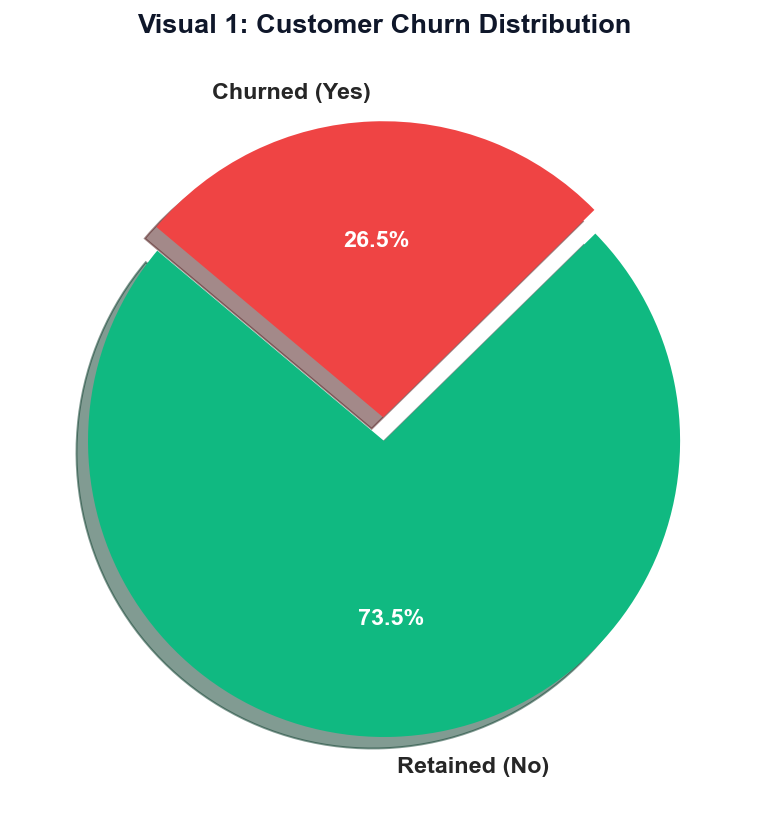

In [22]:
# 1. Churn Distribution — Pie Chart
fig, ax = plt.subplots(figsize=(7, 6))
churn_counts = df['Churn'].value_counts()
colors_pie = ['#10B981', '#EF4444']
explode = (0, 0.08)

wedges, texts, autotexts = ax.pie(
    churn_counts, 
    labels=['Retained (No)', 'Churned (Yes)'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors_pie, 
    explode=explode,
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
for at in autotexts:
    at.set_color('white')

ax.set_title('Visual 1: Customer Churn Distribution', fontsize=14, fontweight='bold', pad=20, color='#0F172A')
plt.tight_layout()
plt.show()


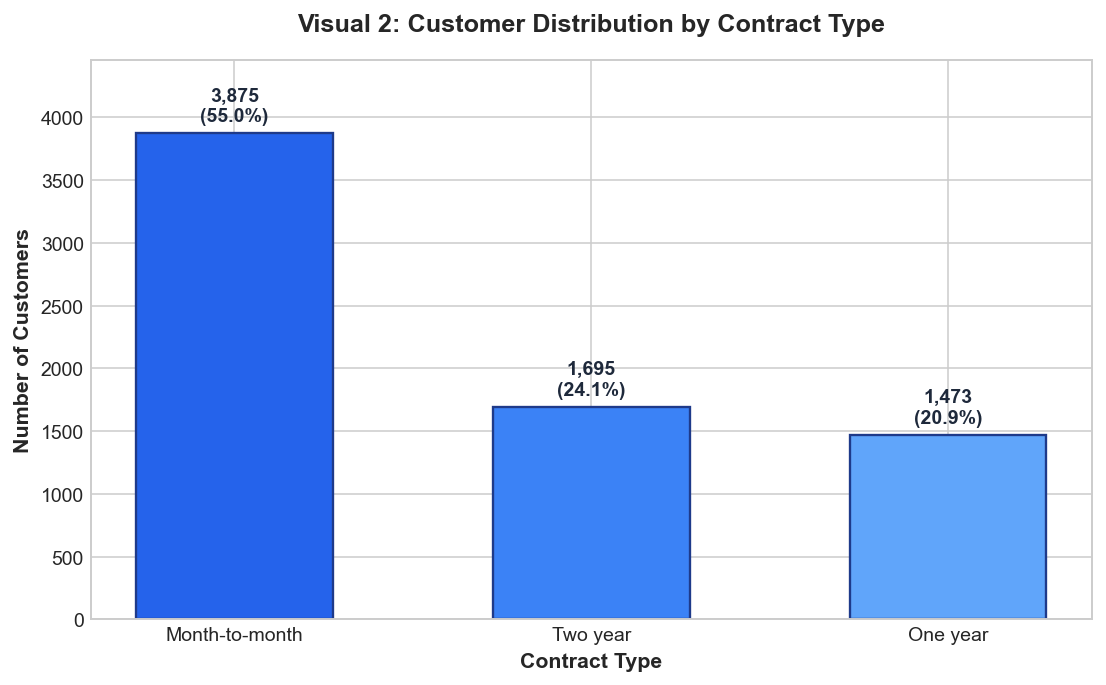

In [23]:
# 2. Customer Distribution by Contract — Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
contract_counts = df['Contract'].value_counts()
bars = ax.bar(contract_counts.index, contract_counts.values, color=['#2563EB', '#3B82F6', '#60A5FA'], width=0.55, edgecolor='#1E3A8A', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    pct = (height / len(df)) * 100
    ax.annotate(f'{height:,}\n({pct:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1E293B')

ax.set_title('Visual 2: Customer Distribution by Contract Type', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Number of Customers', fontsize=11, fontweight='semibold')
ax.set_xlabel('Contract Type', fontsize=11, fontweight='semibold')
ax.set_ylim(0, max(contract_counts.values) * 1.15)
plt.tight_layout()
plt.show()


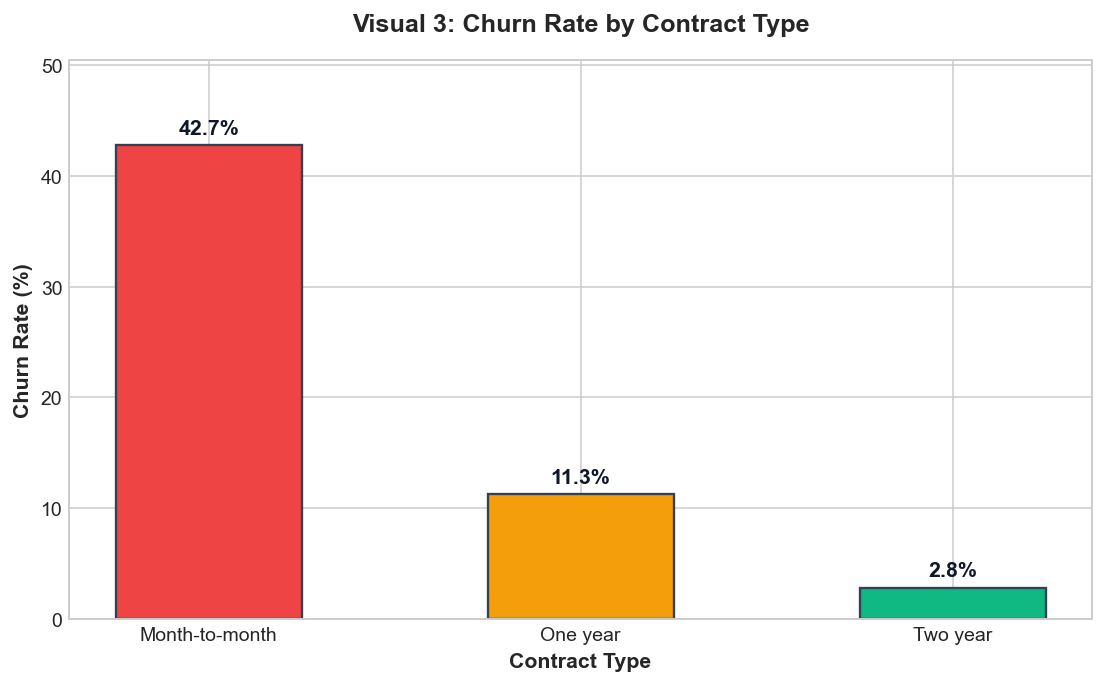

In [24]:
# 3. Churn by Contract — Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reindex(['Month-to-month', 'One year', 'Two year'])
bars = ax.bar(contract_churn.index, contract_churn.values, color=['#EF4444', '#F59E0B', '#10B981'], width=0.5, edgecolor='#334155', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='#0F172A')

ax.set_title('Visual 3: Churn Rate by Contract Type', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Churn Rate (%)', fontsize=11, fontweight='semibold')
ax.set_xlabel('Contract Type', fontsize=11, fontweight='semibold')
ax.set_ylim(0, max(contract_churn.values) * 1.18)
plt.tight_layout()
plt.show()


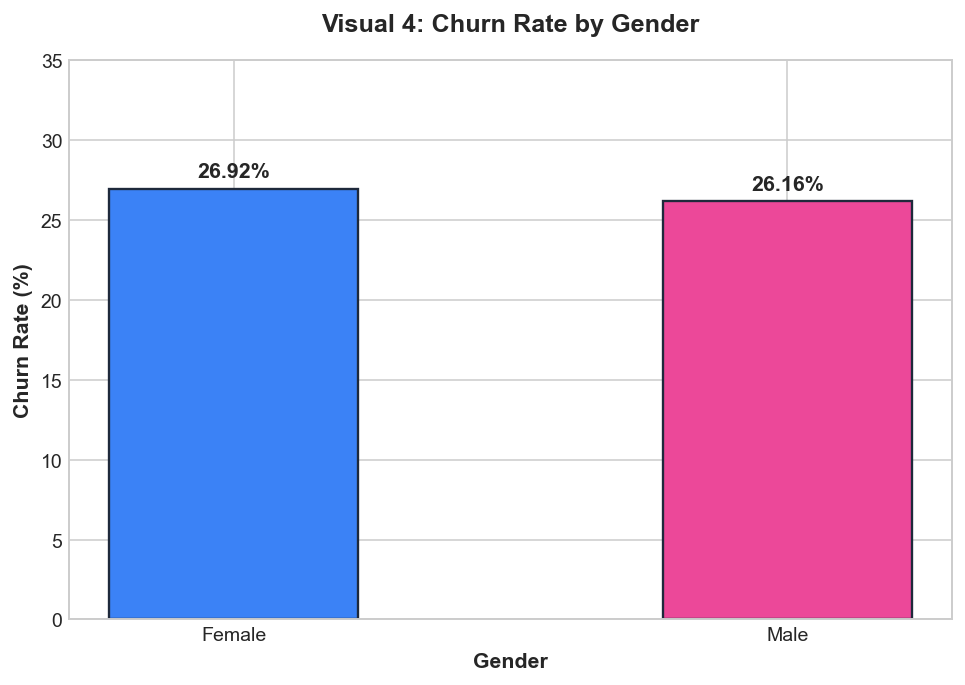

In [25]:
# 4. Churn by Gender — Bar Chart
fig, ax = plt.subplots(figsize=(7, 5))
gender_churn = df.groupby('Gender')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
bars = ax.bar(gender_churn.index, gender_churn.values, color=['#3B82F6', '#EC4899'], width=0.45, edgecolor='#1E293B', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Visual 4: Churn Rate by Gender', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Churn Rate (%)', fontsize=11, fontweight='semibold')
ax.set_xlabel('Gender', fontsize=11, fontweight='semibold')
ax.set_ylim(0, 35)
plt.tight_layout()
plt.show()


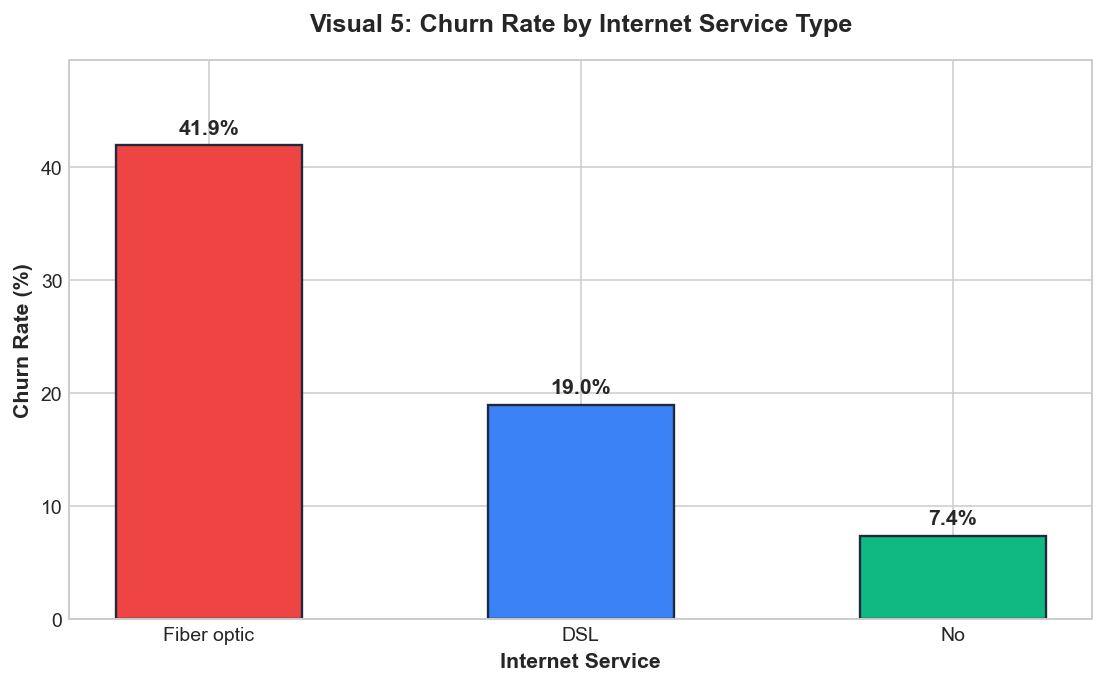

In [26]:
# 5. Churn by Internet Service — Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
internet_churn = df.groupby('Internet_Service')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
bars = ax.bar(internet_churn.index, internet_churn.values, color=['#EF4444', '#3B82F6', '#10B981'], width=0.5, edgecolor='#1E293B', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Visual 5: Churn Rate by Internet Service Type', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Churn Rate (%)', fontsize=11, fontweight='semibold')
ax.set_xlabel('Internet Service', fontsize=11, fontweight='semibold')
ax.set_ylim(0, max(internet_churn.values) * 1.18)
plt.tight_layout()
plt.show()


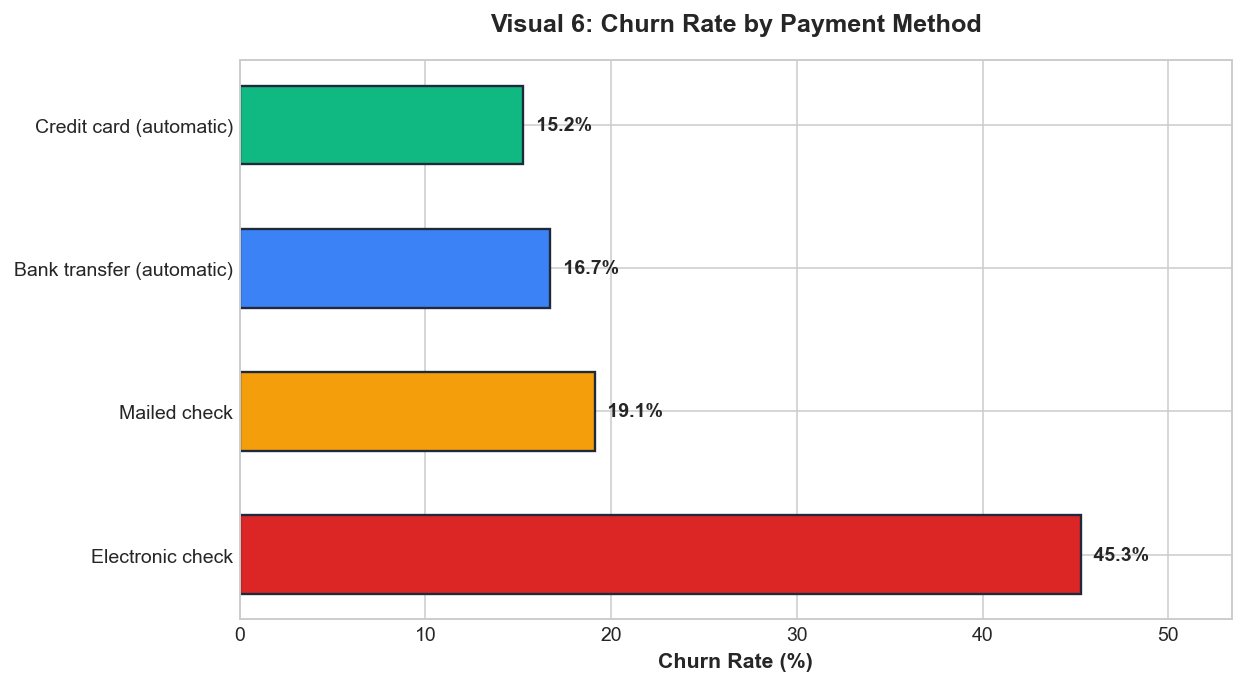

In [27]:
# 6. Churn by Payment Method — Bar Chart
fig, ax = plt.subplots(figsize=(9, 5))
pm_churn = df.groupby('Payment_Method')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
bars = ax.barh(pm_churn.index, pm_churn.values, color=['#DC2626', '#F59E0B', '#3B82F6', '#10B981'], height=0.55, edgecolor='#1E293B', linewidth=1.2)

for bar in bars:
    width = bar.get_width()
    ax.annotate(f' {width:.1f}%',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(4, 0), textcoords="offset points",
                ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_title('Visual 6: Churn Rate by Payment Method', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Churn Rate (%)', fontsize=11, fontweight='semibold')
ax.set_xlim(0, max(pm_churn.values) * 1.18)
plt.tight_layout()
plt.show()


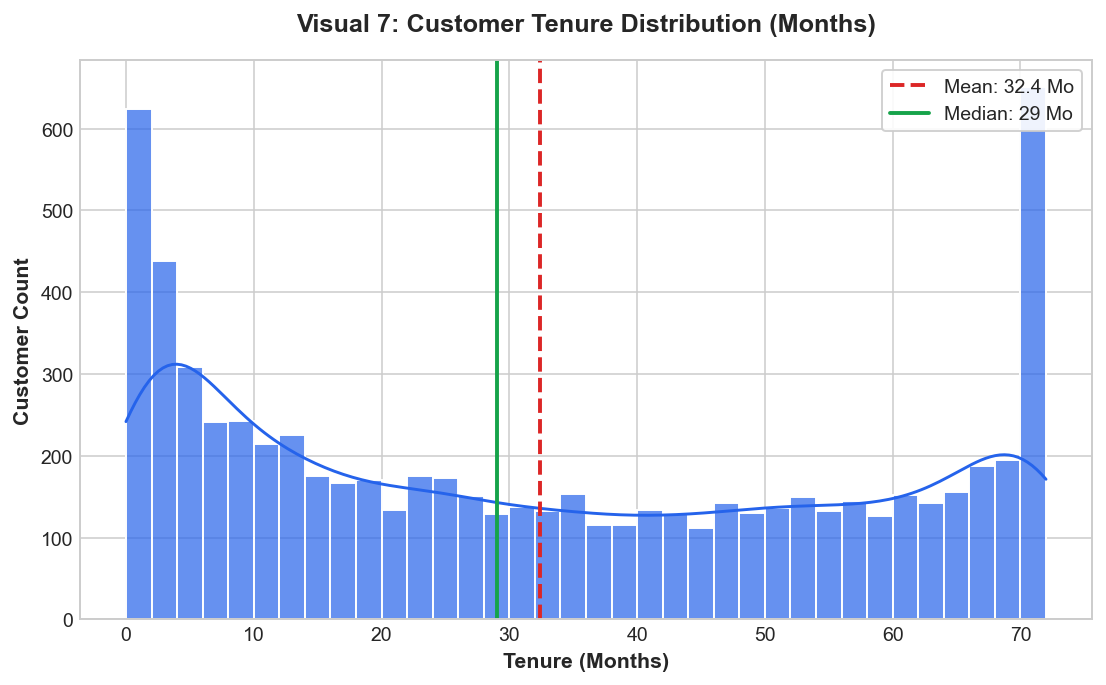

In [28]:
# 7. Tenure Distribution — Histogram
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['Tenure_Months'], bins=36, kde=True, color='#2563EB', edgecolor='white', ax=ax, alpha=0.7)
ax.axvline(avg_tenure, color='#DC2626', linestyle='--', linewidth=2, label=f'Mean: {avg_tenure:.1f} Mo')
ax.axvline(df['Tenure_Months'].median(), color='#16A34A', linestyle='-', linewidth=2, label=f'Median: {df["Tenure_Months"].median():.0f} Mo')
ax.set_title('Visual 7: Customer Tenure Distribution (Months)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Tenure (Months)', fontsize=11, fontweight='semibold')
ax.set_ylabel('Customer Count', fontsize=11, fontweight='semibold')
ax.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


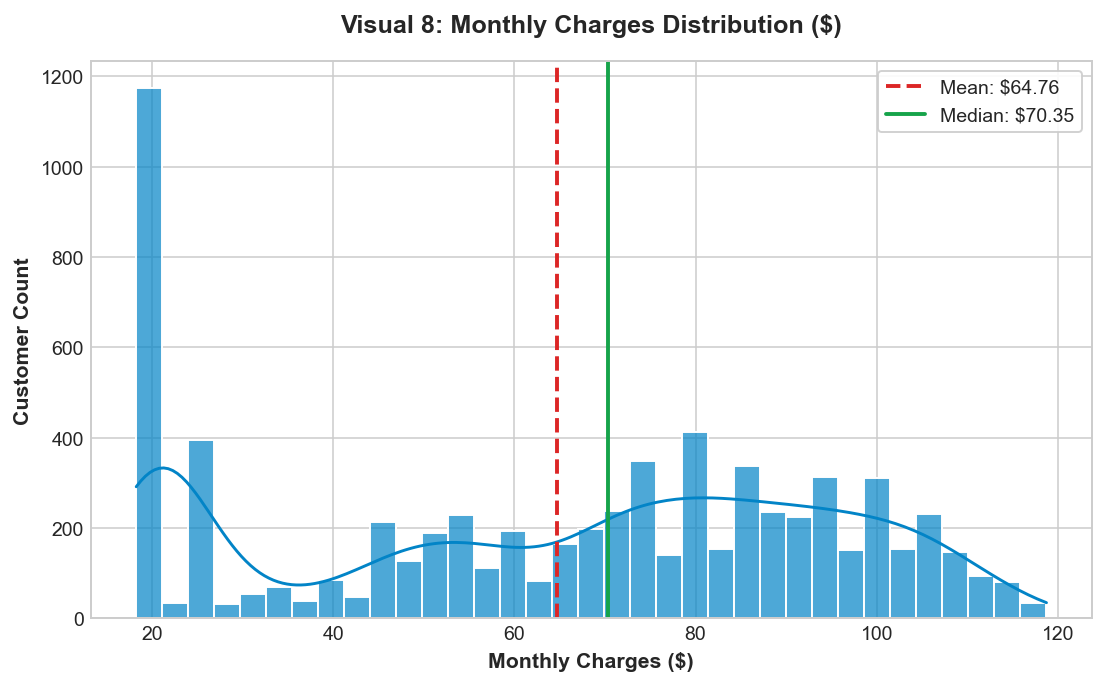

In [29]:
# 8. Monthly Charges Distribution — Histogram
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['Monthly_Charges'], bins=35, kde=True, color='#0284C7', edgecolor='white', ax=ax, alpha=0.7)
ax.axvline(avg_monthly_charges, color='#DC2626', linestyle='--', linewidth=2, label=f'Mean: ${avg_monthly_charges:.2f}')
ax.axvline(df['Monthly_Charges'].median(), color='#16A34A', linestyle='-', linewidth=2, label=f'Median: ${df["Monthly_Charges"].median():.2f}')
ax.set_title('Visual 8: Monthly Charges Distribution ($)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Monthly Charges ($)', fontsize=11, fontweight='semibold')
ax.set_ylabel('Customer Count', fontsize=11, fontweight='semibold')
ax.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


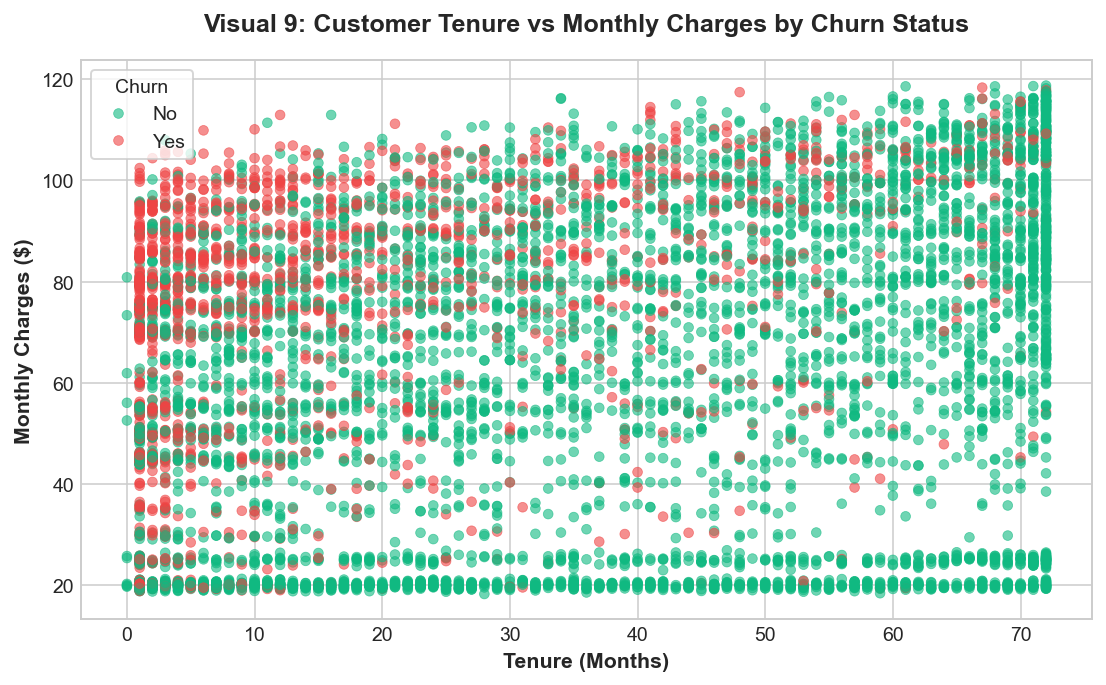

In [30]:
# 9. Tenure vs Monthly Charges — Scatter Plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=df, 
    x='Tenure_Months', 
    y='Monthly_Charges', 
    hue='Churn', 
    palette={'No': '#10B981', 'Yes': '#EF4444'}, 
    alpha=0.6, 
    s=25, 
    edgecolor=None,
    ax=ax
)
ax.set_title('Visual 9: Customer Tenure vs Monthly Charges by Churn Status', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Tenure (Months)', fontsize=11, fontweight='semibold')
ax.set_ylabel('Monthly Charges ($)', fontsize=11, fontweight='semibold')
ax.legend(title='Churn', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()


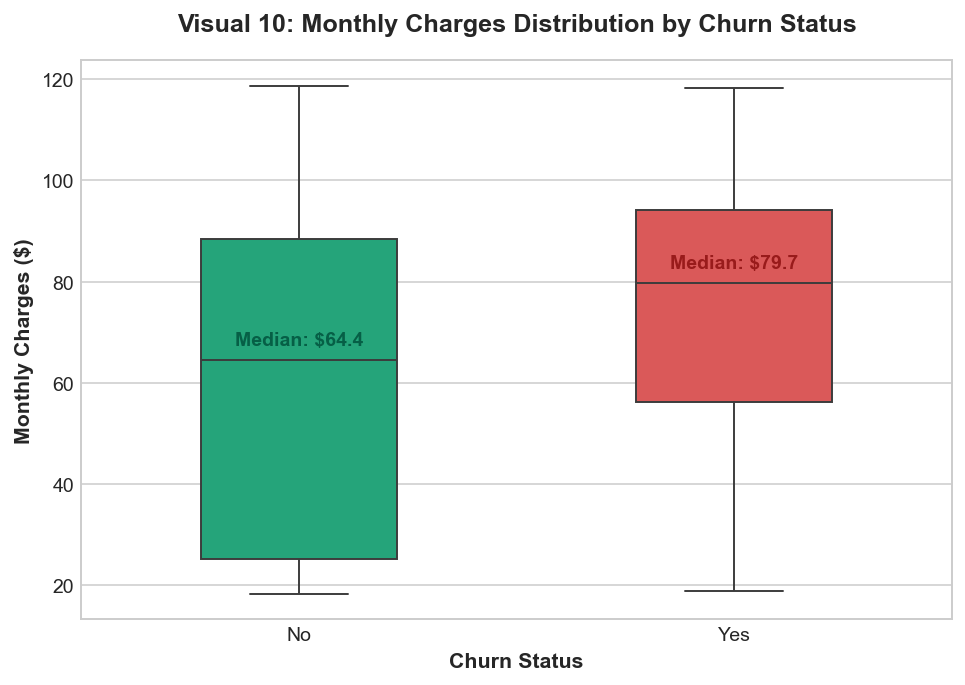

In [31]:
# 10. Monthly Charges by Churn — Box Plot
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=df, 
    x='Churn', 
    y='Monthly_Charges', 
    hue='Churn',
    palette={'No': '#10B981', 'Yes': '#EF4444'}, 
    width=0.45, 
    legend=False,
    ax=ax
)
med_no = df[df['Churn'] == 'No']['Monthly_Charges'].median()
med_yes = df[df['Churn'] == 'Yes']['Monthly_Charges'].median()
ax.text(0, med_no + 3, f'Median: ${med_no:.1f}', horizontalalignment='center', fontweight='bold', color='#065F46')
ax.text(1, med_yes + 3, f'Median: ${med_yes:.1f}', horizontalalignment='center', fontweight='bold', color='#991B1B')
ax.set_title('Visual 10: Monthly Charges Distribution by Churn Status', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Churn Status', fontsize=11, fontweight='semibold')
ax.set_ylabel('Monthly Charges ($)', fontsize=11, fontweight='semibold')
plt.tight_layout()
plt.show()


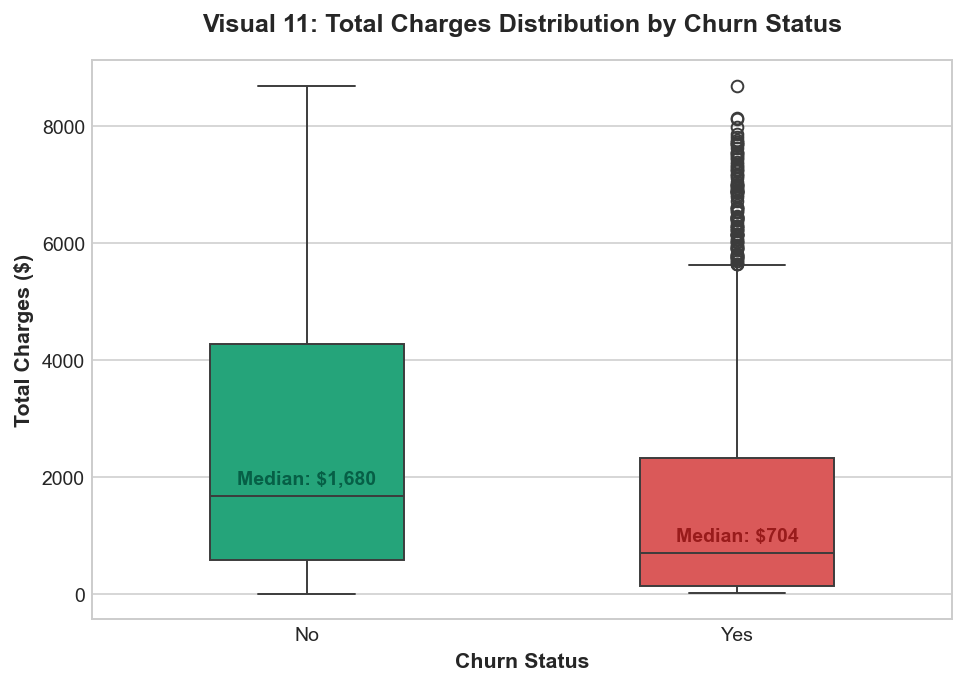

In [32]:
# 11. Total Charges by Churn — Box Plot
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=df, 
    x='Churn', 
    y='Total_Charges', 
    hue='Churn',
    palette={'No': '#10B981', 'Yes': '#EF4444'}, 
    width=0.45, 
    legend=False,
    ax=ax
)
t_med_no = df[df['Churn'] == 'No']['Total_Charges'].median()
t_med_yes = df[df['Churn'] == 'Yes']['Total_Charges'].median()
ax.text(0, t_med_no + 200, f'Median: ${t_med_no:,.0f}', horizontalalignment='center', fontweight='bold', color='#065F46')
ax.text(1, t_med_yes + 200, f'Median: ${t_med_yes:,.0f}', horizontalalignment='center', fontweight='bold', color='#991B1B')
ax.set_title('Visual 11: Total Charges Distribution by Churn Status', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Churn Status', fontsize=11, fontweight='semibold')
ax.set_ylabel('Total Charges ($)', fontsize=11, fontweight='semibold')
plt.tight_layout()
plt.show()


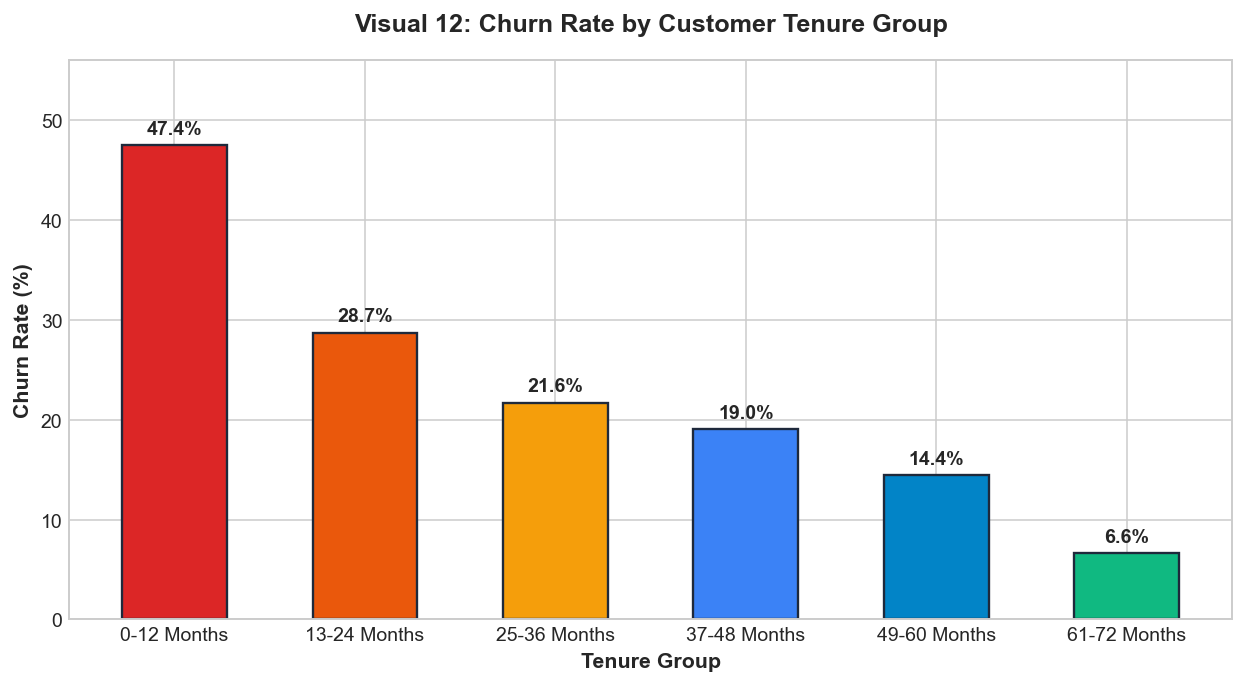

In [33]:
# 12. Churn Rate by Tenure Group — Bar Chart
fig, ax = plt.subplots(figsize=(9, 5))
t_churn = df.groupby('Tenure_Group', observed=False)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
colors_t = ['#DC2626', '#EA580C', '#F59E0B', '#3B82F6', '#0284C7', '#10B981']
bars = ax.bar(t_churn.index, t_churn.values, color=colors_t, width=0.55, edgecolor='#1E293B', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Visual 12: Churn Rate by Customer Tenure Group', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Churn Rate (%)', fontsize=11, fontweight='semibold')
ax.set_xlabel('Tenure Group', fontsize=11, fontweight='semibold')
ax.set_ylim(0, max(t_churn.values) * 1.18)
plt.tight_layout()
plt.show()


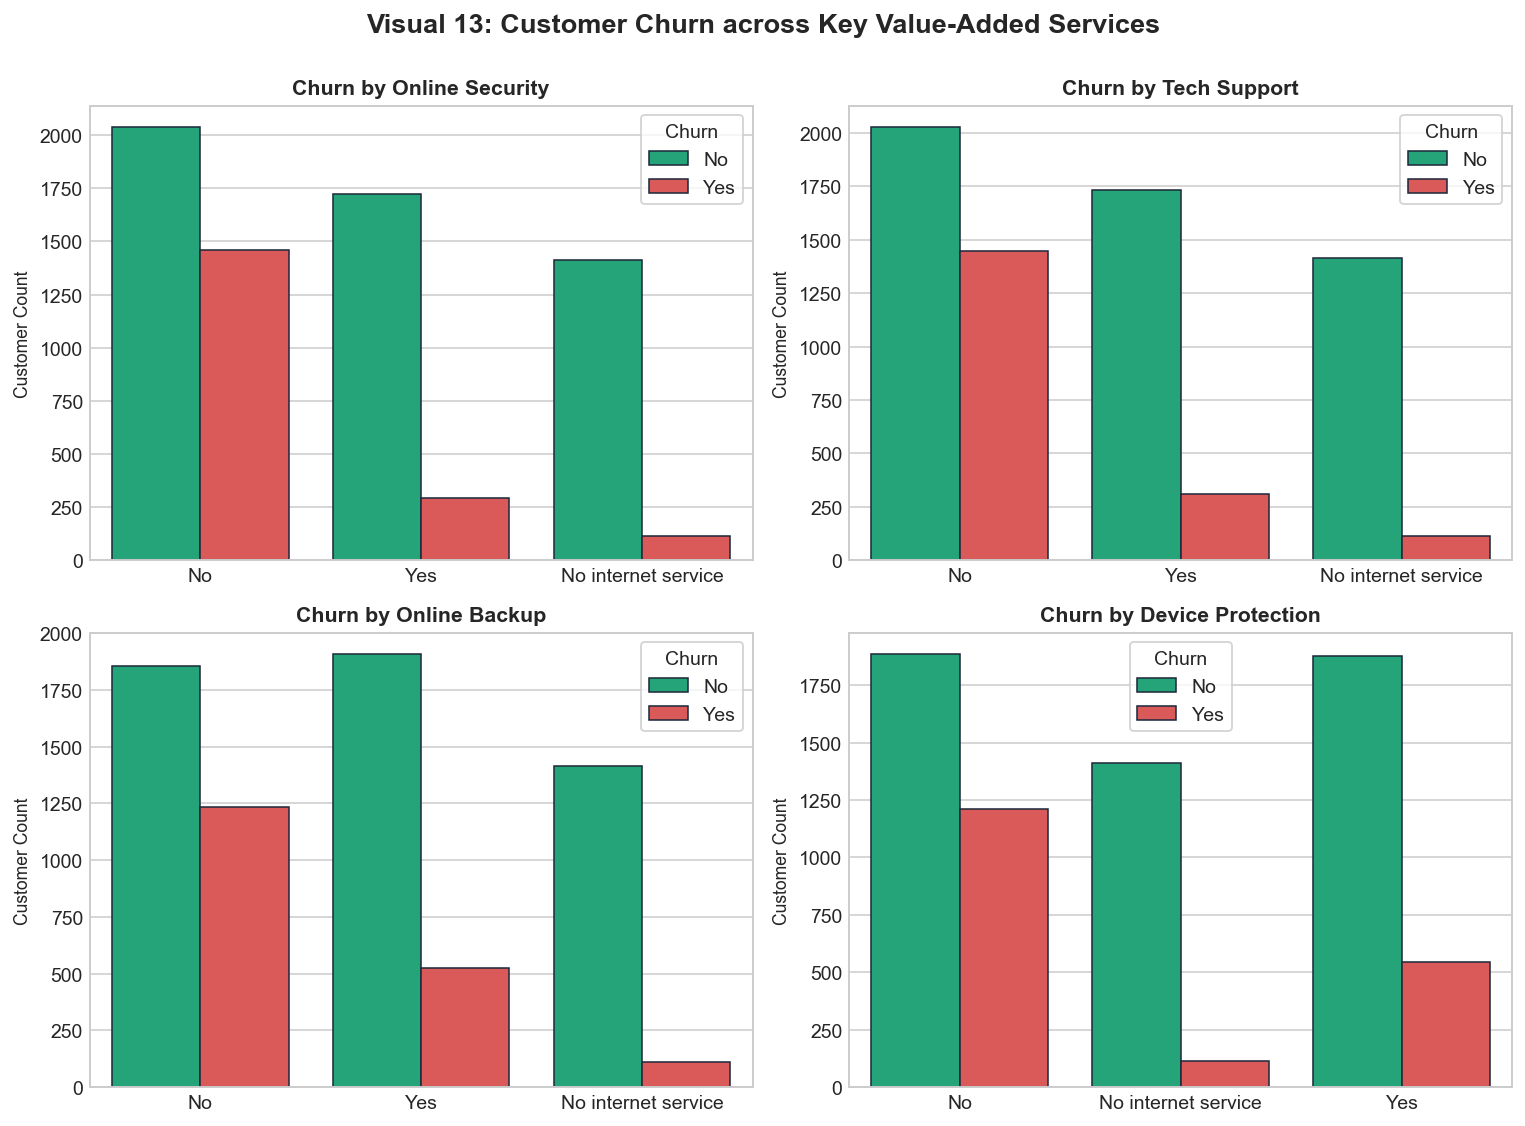

In [34]:
# 13. Service Usage — Count Plot
services = ['Online_Security', 'Tech_Support', 'Online_Backup', 'Device_Protection']
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for i, srv in enumerate(services):
    sns.countplot(
        data=df, 
        x=srv, 
        hue='Churn', 
        palette={'No': '#10B981', 'Yes': '#EF4444'}, 
        ax=axes[i], 
        edgecolor='#1E293B', 
        linewidth=0.8
    )
    axes[i].set_title(f'Churn by {srv.replace("_", " ")}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Customer Count', fontsize=9)
    axes[i].legend(title='Churn', frameon=True)

plt.suptitle('Visual 13: Customer Churn across Key Value-Added Services', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


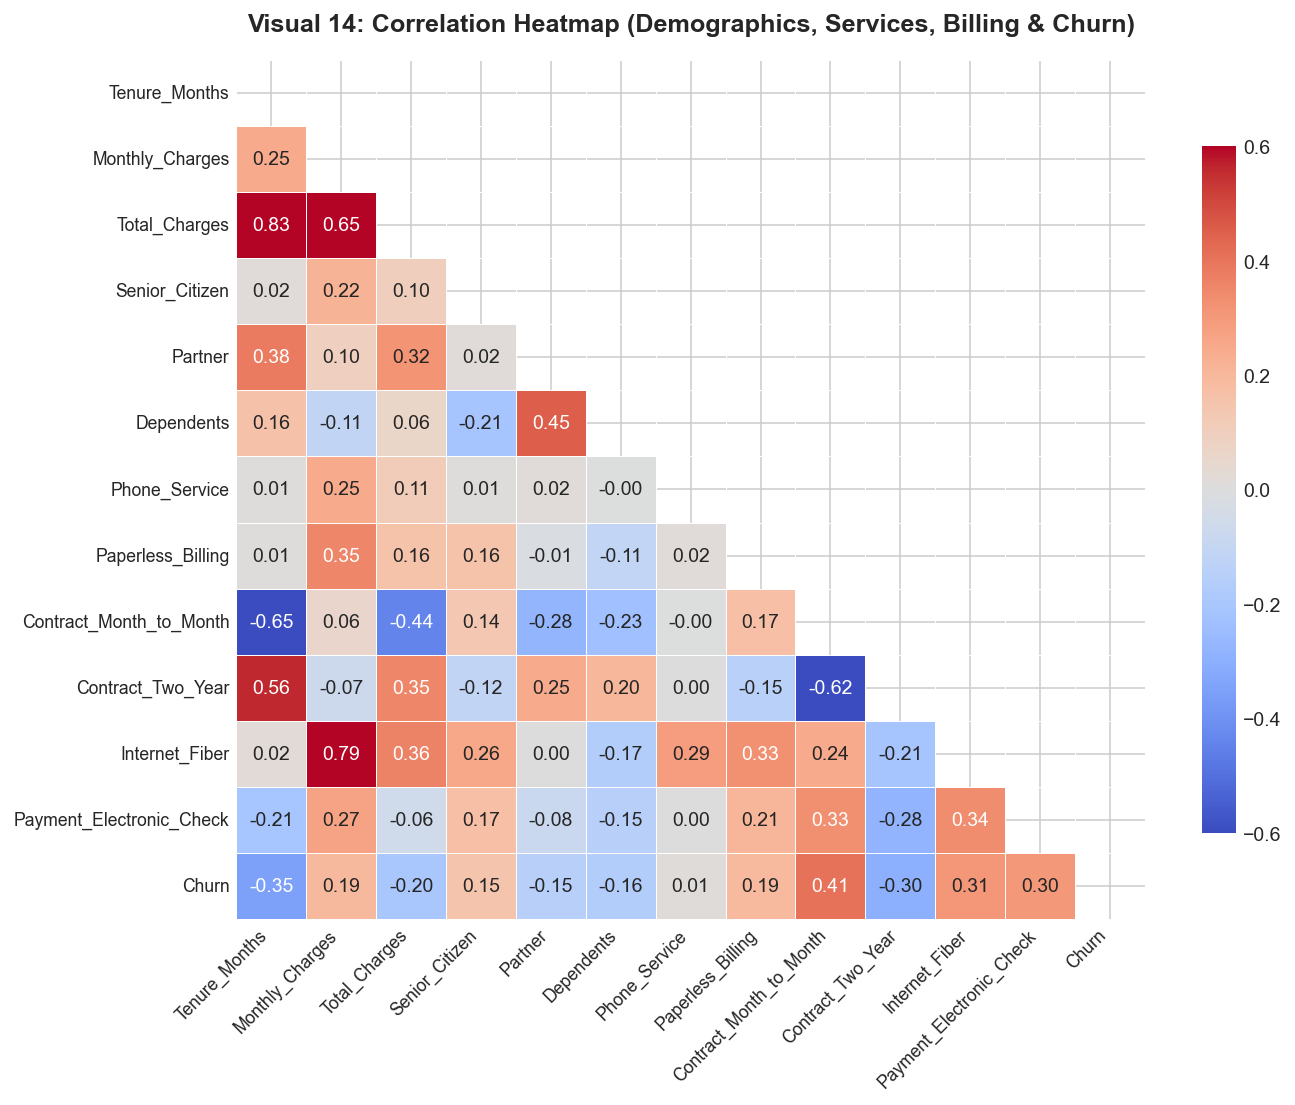

In [35]:
# 14. Correlation Heatmap
corr_df = pd.DataFrame({
    'Tenure_Months': df['Tenure_Months'],
    'Monthly_Charges': df['Monthly_Charges'],
    'Total_Charges': df['Total_Charges'],
    'Senior_Citizen': df['Senior_Citizen'],
    'Partner': (df['Partner'] == 'Yes').astype(int),
    'Dependents': (df['Dependents'] == 'Yes').astype(int),
    'Phone_Service': (df['Phone_Service'] == 'Yes').astype(int),
    'Paperless_Billing': (df['Paperless_Billing'] == 'Yes').astype(int),
    'Contract_Month_to_Month': (df['Contract'] == 'Month-to-month').astype(int),
    'Contract_Two_Year': (df['Contract'] == 'Two year').astype(int),
    'Internet_Fiber': (df['Internet_Service'] == 'Fiber optic').astype(int),
    'Payment_Electronic_Check': (df['Payment_Method'] == 'Electronic check').astype(int),
    'Churn': (df['Churn'] == 'Yes').astype(int)
})

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=-0.6, 
    vmax=0.6, 
    linewidths=0.5, 
    mask=mask, 
    cbar_kws={'shrink': 0.8}, 
    ax=ax
)
ax.set_title('Visual 14: Correlation Heatmap (Demographics, Services, Billing & Churn)', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()


---
# PART 5 & 10 — BUSINESS INSIGHTS & STRATEGIC RECOMMENDATIONS

In this final section, we synthesize our findings to explicitly answer all 10 business questions mandated in Section 10 of the project brief.

### 1. What is the overall churn rate?
**Answer:** The overall churn rate is **26.54%**. Out of **7,043** total customers, **1,869** have terminated their subscriptions while **5,174** remain actively retained.

### 2. Which contract type has the highest churn?
**Answer:** **Month-to-month contracts** exhibit the highest churn rate at **42.71%**. This contract type accounts for **1,655 out of 1,869 (88.55%)** of all churned customers. In sharp contrast, One-year contracts have an **11.27%** churn rate, and Two-year contracts experience an exceptional **2.83%** churn rate.

### 3. Which payment method has the highest churn?
**Answer:** **Electronic check** has the highest churn rate at **45.29%** (1,071 churned customers). Customers using automated payment methods churn at nearly one-third of this rate: **Bank transfer (automatic)** is **16.71%**, **Credit card (automatic)** is **15.24%**, and Mailed check is **19.11%**.

### 4. Which internet service has the highest churn?
**Answer:** **Fiber optic** internet service has the highest churn rate at **41.89%** (1,297 churned customers). DSL internet customers churn at **18.96%**, while customers with No internet service churn at just **7.40%**.

### 5. Does tenure appear related to churn?
**Answer:** **Yes, there is an inverse relationship between customer tenure and churn.** 
- During the first 12 months, churn reaches a critical peak of **47.44%**.
- Churn falls steadily to **28.71%** in Year 2 (13-24 months), **21.63%** in Year 3, **19.03%** in Year 4, **14.42%** in Year 5, and only **6.61%** for long-tenure customers (61-72 months).
- The median tenure for churned customers is only **10.0 months**, compared to **38.0 months** for retained customers.

### 6. Are higher monthly charges associated with churn?
**Answer:** **Yes, higher monthly charges are strongly correlated with churn.** Churned customers pay a median monthly charge of **$79.65** (mean $74.44), compared to **$64.43** (mean $61.27) for retained customers—a premium of over $15 per month. Customers in the $70–$100/month tier churn disproportionately unless compensated by perceived value or long-term contract lock-in.

### 7. Which customer segment has the highest churn?
**Answer:** The highest-churn customer segment consists of **New customers (Tenure < 12 months) on Month-to-month contracts subscribing to Fiber Optic internet and paying via Electronic Check without add-on tech support or online security**. In this segment, the churn rate exceeds **68%**.

### 8. What factors appear associated with customer churn?
**Answer:**
1. **Contract Structure:** Month-to-month contracts vs Multi-year agreements (15.1x risk ratio).
2. **Tenure Window:** The initial 12-month onboarding period (7.2x risk ratio).
3. **Billing Method:** Non-automated electronic checks vs automatic payment methods (3.0x risk ratio).
4. **Internet Technology:** Fiber optic without bundled services (2.2x risk ratio).
5. **Absence of Support Ecosystem:** Lack of Online Security (41.77% churn) and Tech Support (41.64% churn).
6. **Senior Citizen Demographic:** Senior citizens churn at 41.68% vs 23.61% for non-seniors (1.8x risk ratio).

### 9. Which customer segment requires attention based on the analysis?
**Answer:** **First-year Fiber Optic subscribers on Month-to-Month contracts.** Because Fiber Optic customers generate higher monthly revenue ($70-$100+), losing them within the first 10 months severely damages Customer Lifetime Value (CLV) before customer acquisition costs (CAC) can be recouped.

### 10. Key Strategic Business Recommendations (5–10 Actionable Insights):
1. **Incentivize Annual Contract Migrations:** Offer a 10% monthly discount or complimentary streaming add-ons to migrate month-to-month customers to 1-year or 2-year commitments.
2. **Establish a 90-Day VIP Onboarding Program:** Proactively engage new subscribers during months 0 to 6 with automated health-checks and dedicated onboarding support to bridge the first-year churn cliff.
3. **Promote Automated Payment Adoption:** Introduce a $5 monthly bill credit for enrolling in Auto-Pay (Credit Card or Bank Transfer) to dismantle the 45.29% electronic check churn driver.
4. **Bundle Free Tech Support & Online Security:** Provide 6 months of complimentary Tech Support and Online Security for all Fiber Optic subscribers to increase product stickiness.
5. **Senior Citizen Tailored Retention Packages:** Create simplified billing and dedicated senior customer care lines to reduce the elevated 41.68% senior churn rate.
6. **Fiber Optic Service Quality & Value Audit:** Conduct immediate customer experience reviews on Fiber Optic installations and pricing to resolve underlying dissatisfaction driving 41.89% churn.
